# Imports

In [2]:
import os
import sys

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [5]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [7]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [8]:

dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j*Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [9]:
Qmax = max(np.hypot(u,v))
Qmin = (np.unique(np.hypot(u,v))[1:]).min()

In [10]:
Rmax = 3*rout

import math

N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

In [11]:
Qmax

8828201.715647701

In [12]:
N

642

In [13]:
routs = [rout, 2*rout, 3*rout, 4*rout, 5*rout, 6*rout]

In [14]:

print(f"-> q_min data: {Qmin}, q_max data: {Qmax}")

for i in range(len(routs)):
    print("N =", N)
    print("Rmax =", routs[i])
    frank2d = Frank2D(N, routs[i])
    cellsize = 2*routs[i]/N
    print(f"-> cellsize: {cellsize} arcsec")


    q_min_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[1]
    q_max_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[-1]
    print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")

-> q_min data: 11479.95169238425, q_max data: 8828201.715647701
N = 642
Rmax = 1
-> cellsize: 0.003115264797507788 arcsec
-> q_min frank2d: 145851.2432174512, q_max frank2d: 46818249.07280183
N = 642
Rmax = 2
-> cellsize: 0.006230529595015576 arcsec
-> q_min frank2d: 72925.6216087256, q_max frank2d: 23409124.536400914
N = 642
Rmax = 3
-> cellsize: 0.009345794392523364 arcsec
-> q_min frank2d: 48617.081072483736, q_max frank2d: 15606083.02426728
N = 642
Rmax = 4
-> cellsize: 0.012461059190031152 arcsec
-> q_min frank2d: 36462.8108043628, q_max frank2d: 11704562.268200457
N = 642
Rmax = 5
-> cellsize: 0.01557632398753894 arcsec
-> q_min frank2d: 29170.248643490235, q_max frank2d: 9363649.814560367
N = 642
Rmax = 6
-> cellsize: 0.018691588785046728 arcsec
-> q_min frank2d: 24308.540536241868, q_max frank2d: 7803041.51213364


In [15]:
times_N50_Rmax1 =  4756.382252931595/60 #mins
times_N50_Rmax2 = 2756.394961833954 /60 
times_N50_Rmax3 =  9501.754703044891/60
times_N50_Rmax4 =  12440.519505262375/60
times_N50_Rmax5 = 9037.916426181793/60
times_N50_Rmax6 =  11000.15468287468/60


times_with_opt = [times_N50_Rmax1, times_N50_Rmax2, times_N50_Rmax3, times_N50_Rmax4, times_N50_Rmax5, times_N50_Rmax6]

In [16]:
best_N50_Rmax1 = {'m': -6.3666741693035425, 'c': 5.938938246794921e+34, 'l': 10000.0}
best_N50_Rmax2 = {'m': -3.3890156358896206, 'c': 3.5614791421537604e+16, 'l': 10000.0}
best_N50_Rmax3 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
best_N50_Rmax4 =  {'m': -1.5044655505440632, 'c': 238394.1726792642, 'l': 38670.982529532164}
best_N50_Rmax5 =  {'m': -1.972719134084518, 'c': 58157011.81131077, 'l': 26595.265124130965}
best_N50_Rmax6 =   {'m': -2.2313765094040368, 'c': 828789189.6537628, 'l': 18714.93162241083}

### Load objects

In [17]:
# load objects
frank2d_objects = []
import pickle
dir_ = "./../../data/exp/Rmax_N/"
for i in range(len(routs)):
    with open(dir_ + "SimulatedBlob_N"+str(N)+"_Rmax"+str(routs[i])+ ".pkl", "rb") as file:
        frank2d = pickle.load(file)
        frank2d_objects.append(frank2d)

### Run frank2d for differents N

In [17]:
frank2d_objects = []

In [18]:
times = []

In [19]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

In [21]:
params = [best_N50_Rmax1, best_N50_Rmax2, best_N50_Rmax3, best_N50_Rmax4, best_N50_Rmax5, best_N50_Rmax6]

In [22]:
for i in range(len(routs)):
    start = time.time()
    frank2d = Frank2D(N, routs[i])
    frank2d.process_vis(uvtable)

    frank2d.fit(data = uvtable, kernel_params = params[i], rtol = 1e-10)
    #save object

    import pickle
    dir_ = "./../../data/exp/Rmax_N/"
    print("Saving Frank2D object with Rmax =", routs[i])
    with open(dir_ +"SimulatedBlob_N"+str(N)+"_Rmax"+str(routs[i])+ ".pkl", "wb") as file:
        pickle.dump(frank2d, file)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout ={routs[i]} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -6.3666741693035425, 'c': 5.938938246794921e+34, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.00  min |  0.14 seconds
        +  Building system = 0.00  min |  0.14 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 0/50000 [00:00<?, ? iterations/s]


            +  BiCGStab = 0.00  min |  0.08 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.12837274449980327,
 'iterations': 0,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.62 seconds
--> times building full visibility model = 0.11  min |  6.63 seconds
Saving Frank2D object with Rmax = 1
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =1 took 8.03193211555481 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.3890156358896206, 'c': 3.5614791421537604e+16, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.42 seconds
        +  Building system = 0.01  min |  0.42 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 0/50000 [00:00<?, ? iterations/s]

            +  BiCGStab = 0.00  min |  0.05 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.10082246852331034,
 'iterations': 0,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...


...

            +  BiCGStab = 0.44  min |  26.14 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.058300618130534054,
 'iterations': 273,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  7.45 seconds
--> times building full visibility model = 0.12  min |  7.48 seconds
Saving Frank2D object with Rmax = 4
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =4 took 40.72961235046387 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.972719134084518, 'c': 58157011.81131077, 'l': 26595.265124130965}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  3.10 seconds
        +  Building system = 0.05  min |  3.17 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 186/50000 [00:17<1:16:23, 10.87 iterations/s]


            +  BiCGStab = 0.29  min |  17.12 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.04957831918448404,
 'iterations': 186,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.74 seconds
--> times building full visibility model = 0.11  min |  6.77 seconds
Saving Frank2D object with Rmax = 5
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =5 took 31.558791875839233 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.2313765094040368, 'c': 828789189.6537628, 'l': 18714.93162241083}
===>  Creating sparse linear system...
        +  Kernel = 0.06  min |  3.50 seconds
        +  Building system = 0.06  min |  3.57 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 95/50000 [00:08<1:18:21, 10.62 iterations/s]


            +  BiCGStab = 0.15  min |  8.95 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.042398613480027665,
 'iterations': 95,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.50 seconds
--> times building full visibility model = 0.11  min |  6.53 seconds
Saving Frank2D object with Rmax = 6
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =6 took 24.006016492843628 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


### Complexity plot 

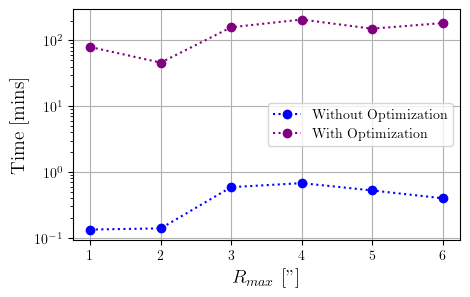

In [86]:
plt.figure(figsize=(5,3))
plt.plot(routs, np.array(times)/60, marker='o', ls=':', color = 'blue', label='Without Optimization')
plt.plot(routs, np.array(times_with_opt), marker='o', ls=':', color = 'purple', label='With Optimization')
plt.xlabel( r'$R_{max}$ ["]', fontsize=14)
plt.ylabel('Time [mins]', fontsize=14)
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

In [89]:
opt_time_rmax1 = times_with_opt[0] - times[0]/60
opt_time_rmax2 = times_with_opt[1] - times[1]/60
opt_time_rmax3 = times_with_opt[2] - times[2]/60
opt_time_rmax4 = times_with_opt[3] - times[3]/60
opt_time_rmax5 = times_with_opt[4] - times[4]/60
opt_time_rmax6 = times_with_opt[5] - times[5]/60
opt_time = [opt_time_rmax1, opt_time_rmax2, opt_time_rmax3, opt_time_rmax4, opt_time_rmax5, opt_time_rmax6]
opt_time

[79.13917201360067,
 45.80040846268336,
 157.7723855495453,
 206.66316488186519,
 150.10596057176588,
 182.93581110636396]

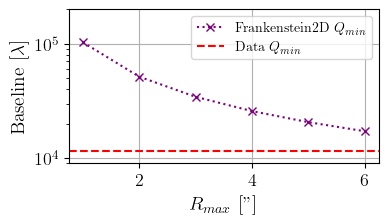

In [27]:
q_min = []
for i in range(len(routs)):
    q_min.append(np.min((np.unique(frank2d_objects[i].FT.q)[1:])))

plt.figure(figsize=(4,2))
plt.plot(routs, np.array(q_min), marker='x', ls=':', color = 'purple', label='Frankenstein2D $Q_{min}$')
plt.axhline(y= Qmin, color='r', linestyle='--', label=r'Data $Q_{min}$')
plt.xlabel( r'$R_{max}$ ["]', fontsize=14)
plt.ylabel(r'Baseline [$\lambda$]', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.yscale('log')
plt.ylim(9e3, 2e5)
plt.legend()
plt.grid()
plt.show()

In [28]:
q_min

[103132.40312354818,
 51566.20156177409,
 34377.4677078494,
 25783.100780887045,
 20626.480624709635,
 17188.7338539247]

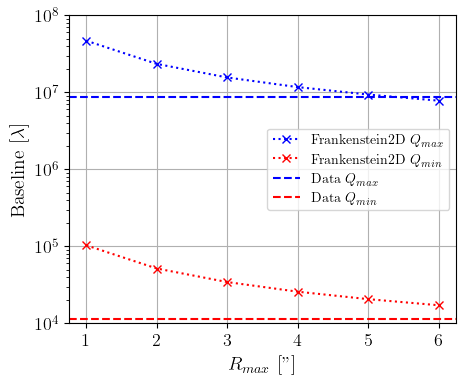

In [64]:
q_max = []
for i in range(len(routs)):
    q_max.append(np.max(frank2d_objects[i].FT.q))

plt.figure(figsize=(5,4))
plt.plot(routs, np.array(q_max), marker='x', ls=':', color = 'blue', label='Frankenstein2D $Q_{max}$')
plt.plot(routs, np.array(q_min), marker='x', ls=':', color = 'red', label='Frankenstein2D $Q_{min}$')
plt.axhline(y= Qmax, color='blue', linestyle='--', label=r'Data $Q_{max}$')
plt.axhline(y= Qmin, color='r', linestyle='--', label=r'Data $Q_{min}$')
plt.xlabel( r'$R_{max}$ ["]', fontsize=14)
plt.ylabel(r'Baseline [$\lambda$]', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.yscale('log')
plt.ylim(1e4, 1e8)
plt.legend()
plt.grid()
plt.show()

In [69]:
q_max

[93636498.14560366,
 46818249.07280183,
 31212166.04853456,
 23409124.536400914,
 18727299.629120734,
 15606083.02426728]

### Plot differents results

In [18]:
fluxs = []
cellsizes = []

xxxxxxxxxxxx Total flux:  [0.77633753]


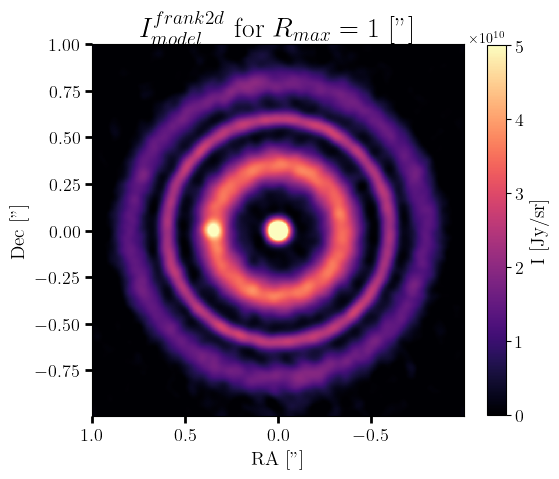

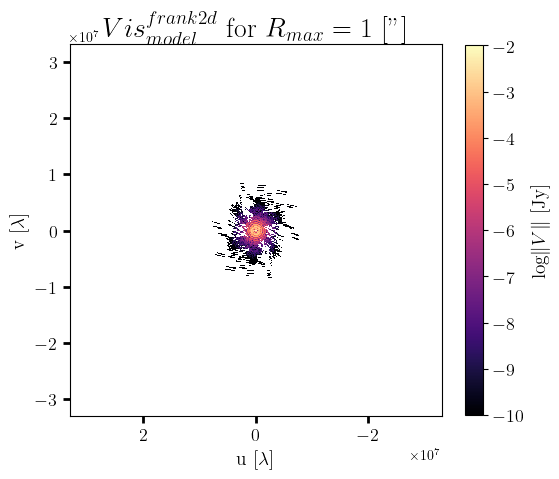

xxxxxxxxxxxx Total flux:  [0.86772992]


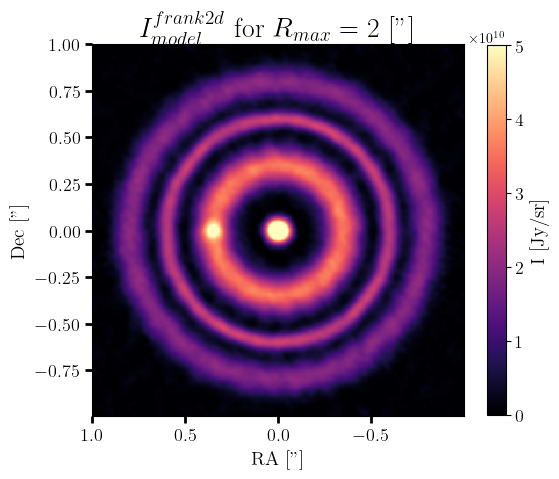

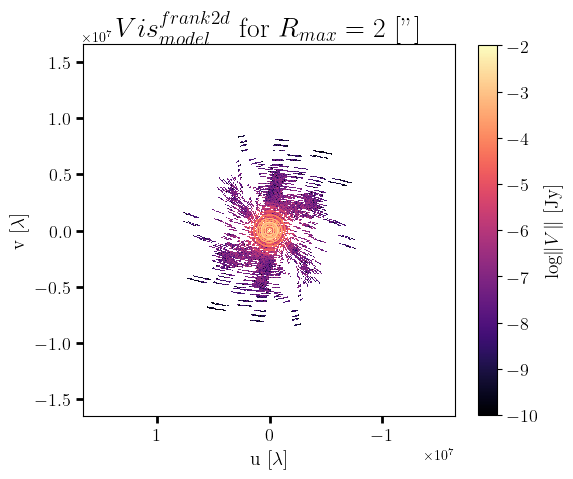

xxxxxxxxxxxx Total flux:  [0.87868756]


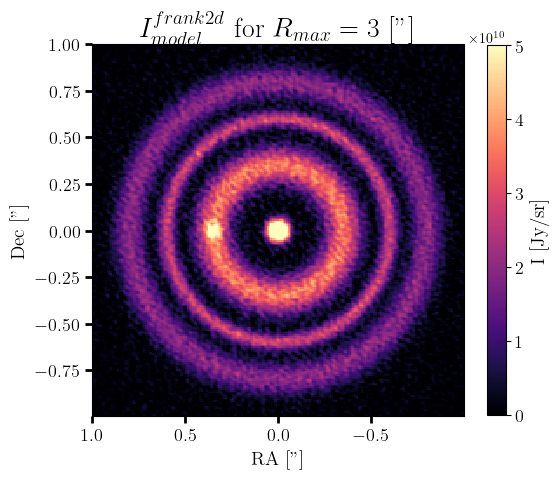

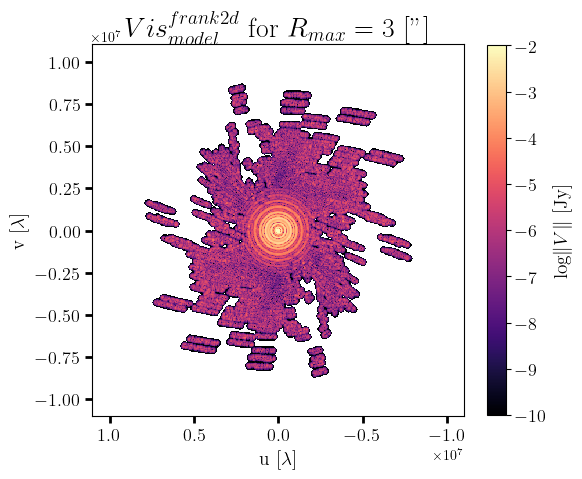

xxxxxxxxxxxx Total flux:  [0.8869046]


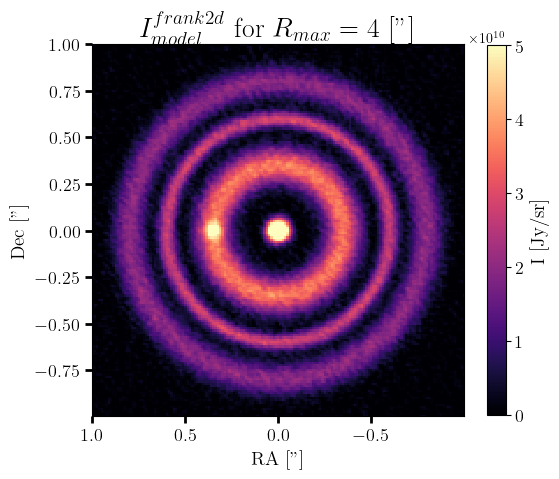

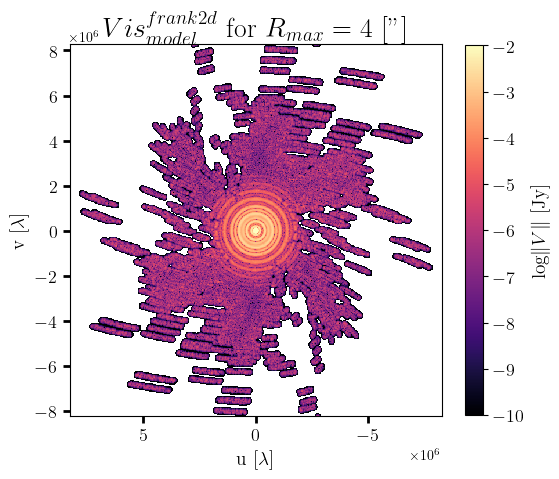

xxxxxxxxxxxx Total flux:  [0.88852901]


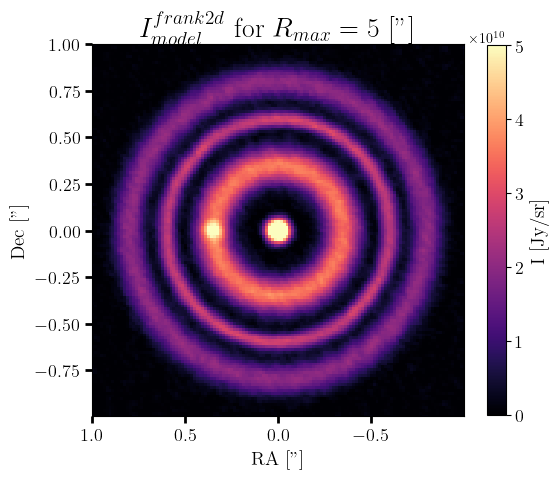

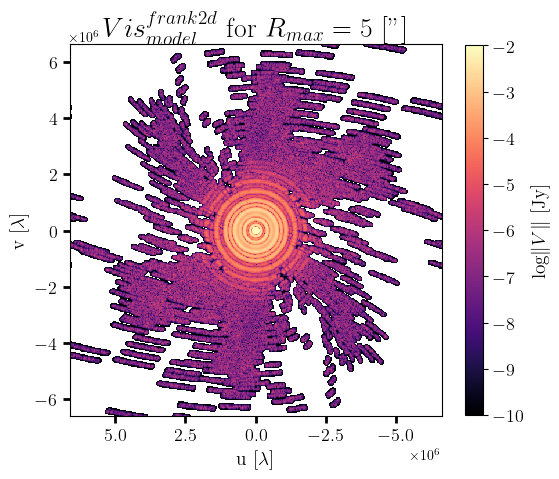

xxxxxxxxxxxx Total flux:  [0.45495064]


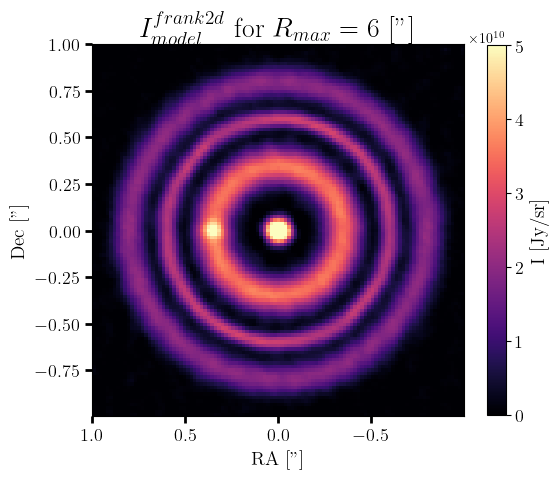

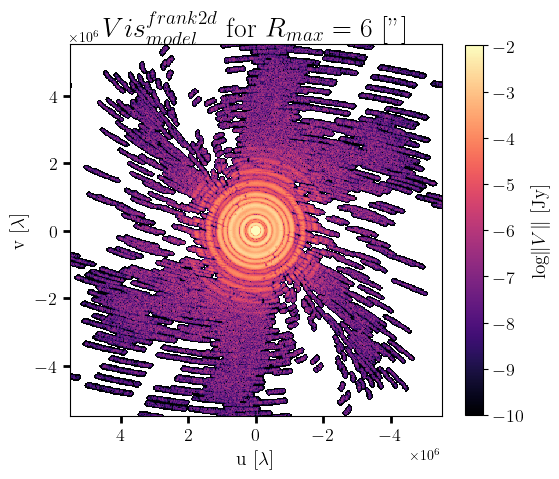

In [19]:
zoom = 1
for i in range(len(routs)):
    Plot_ = Plot(frank2d_objects[i], geom)
    frank2d = frank2d_objects[i]
    u, v = frank2d.u_grid, frank2d.v_grid
    vis = frank2d.visibility_model

    index = np.where((u == 0) & (v == 0))
    V_00 = vis[index].real
    fluxs.append(V_00)
    cellsizes.append(2*routs[i]/N)
    print("xxxxxxxxxxxx Total flux: ", V_00)
    Plot_.intensity( vmax=5e10,  gamma = 1, zoom=zoom,
                     title= r'$I_{model}^{frank2d}$ for $R_{max}$ = ' + str(routs[i]) + ' ["]')
    Plot_.visibility(fig_size = 6,
                     title = r'$Vis_{model}^{frank2d}$ for $R_{max}$ = ' + str(routs[i])+ ' ["]')
    zoom+=1

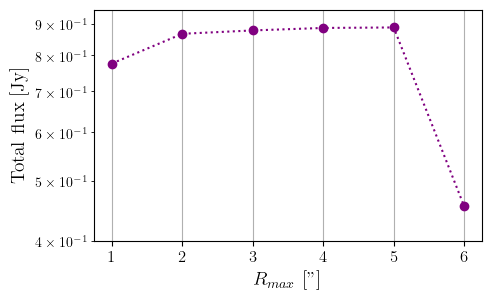

In [87]:
plt.figure(figsize=(5,3))
plt.plot(routs, fluxs, marker='o', ls=':', color = 'purple')
plt.xlabel( r'$R_{max}$ ["]', fontsize=14)
plt.yscale('log')
plt.ylabel('Total flux [Jy]', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim(0.4, 0.95)
plt.grid()

ValueError: x and y must have same first dimension, but have shapes (6,) and (1,)

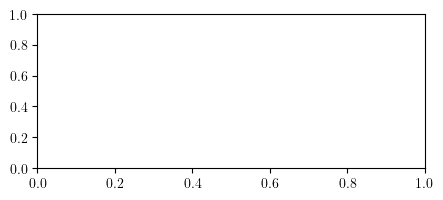

In [20]:
plt.figure(figsize=(5,2))
plt.plot(routs, cellsize, marker='o', ls=':', color = 'purple')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Number of collocation points (N)', fontsize=14)
plt.xlabel( r'$R_{max}$ ["]', fontsize=14)
plt.ylim(0, 0.020)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.ylabel('Pixel size ["]', fontsize=14)
plt.grid()

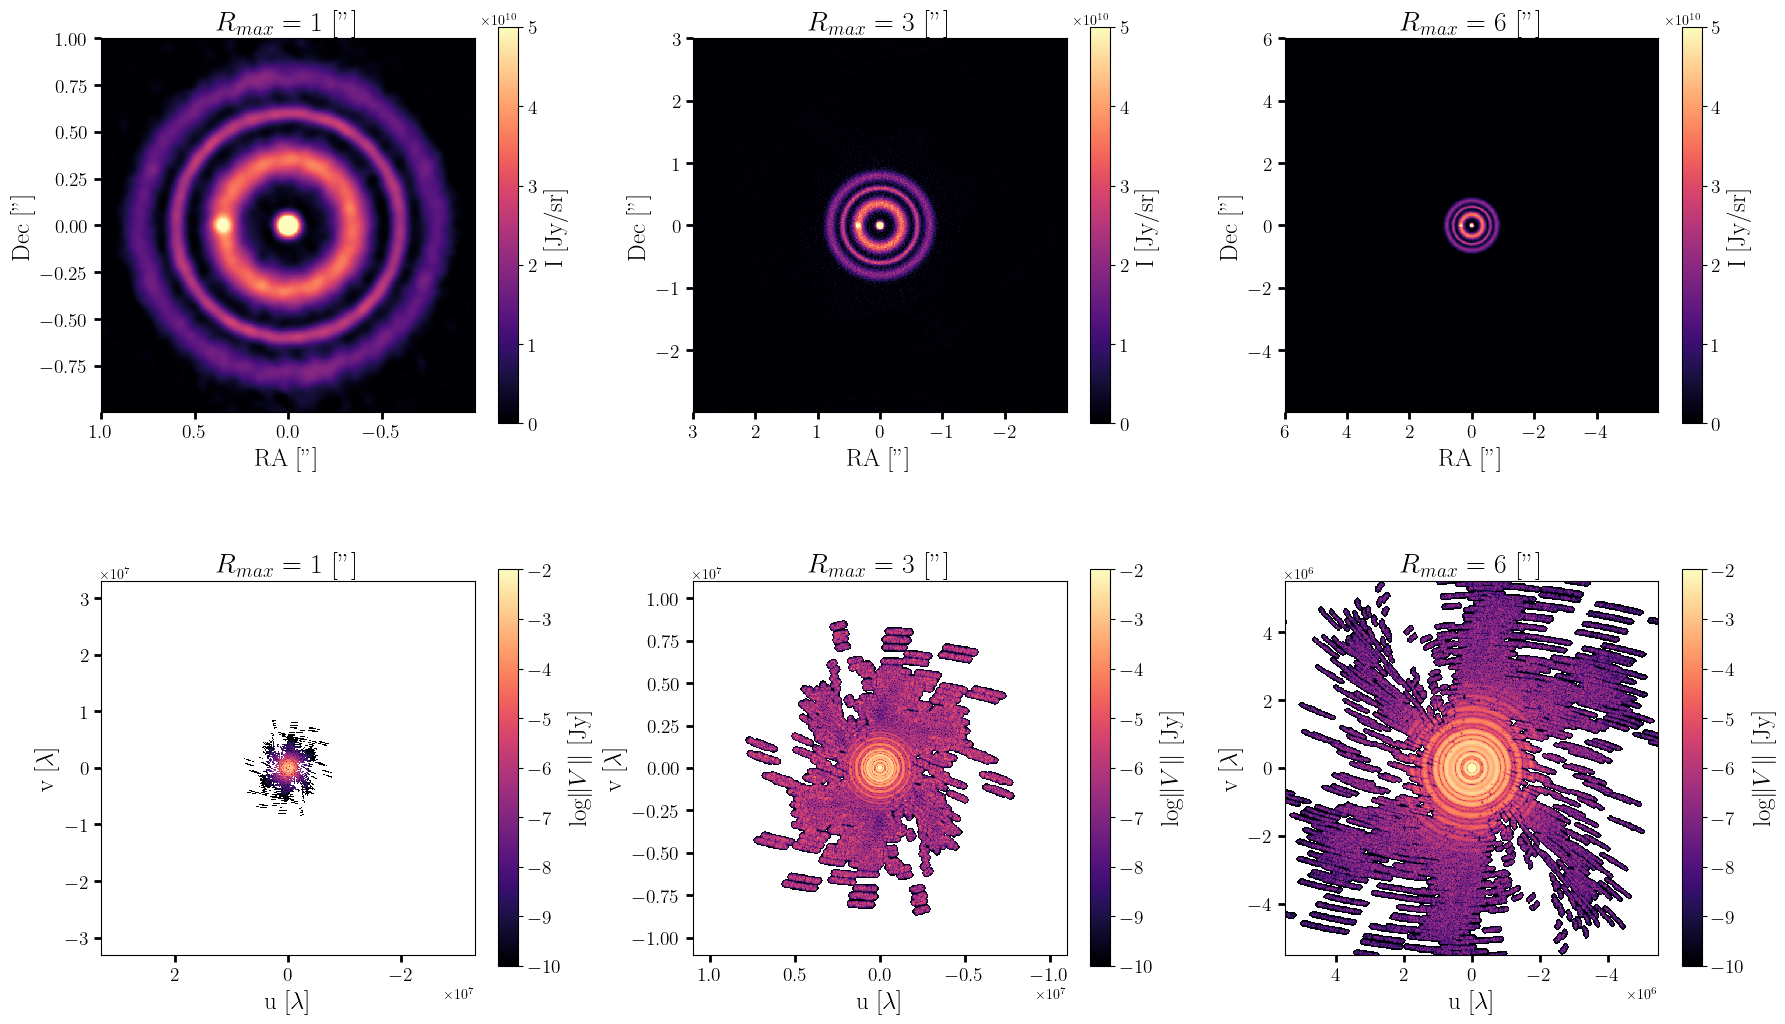

In [22]:
import matplotlib.pyplot as plt

indices_a_plotear = [0, 2, 5]

frank2d_seleccionados = [frank2d_objects[i] for i in indices_a_plotear]
N_seleccionados = [routs[i] for i in indices_a_plotear]

num_cols = len(N_seleccionados)

fig, axes = plt.subplots(nrows=2, ncols=num_cols, figsize=(6 * num_cols, 11))

if num_cols == 1:
    axes = axes.reshape(2, 1)

for i in range(num_cols):
    Plot_ = Plot(frank2d_seleccionados[i], geom) 
    N_valor = N_seleccionados[i] 

    Plot_.intensity(ax=axes[0, i], vmax=5e10, gamma=1, zoom=1,
                     title=r'$R_{max}$ = ' + str(N_valor)+ ' ["]', label_size = 18, tick_label_size=14)
    
    Plot_.visibility(ax=axes[1, i], fig_size=6,
                      title=r'$R_{max}$ = ' + str(N_valor) + ' ["]', label_size = 18,  tick_label_size=14)

plt.tight_layout()
plt.show()